---
#  US Traffic Accidents — Severity Prediction (Part B: Machine Learning)

**Dataset:** `cleaned_accidents.csv` (output of Part A — Data Analysis notebook)  
**Goal:** Predict accident **Severity** (1–4) from weather, time and road-infrastructure features  
**Models:** Logistic Regression (baseline) → Random Forest → XGBoost, compared and evaluated  
---

# **1. Setup**

### **1.1 Import Required Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
print('xgboost version:', xgb.__version__)

xgboost version: 3.4.0


### **1.2 Load Cleaned Dataset**

In [2]:
USE_DRIVE = True
DRIVE_PATH = '/content/drive/MyDrive/cleaned_accidents.csv'

try:
    from google.colab import drive, files
    if USE_DRIVE:
        drive.mount('/content/drive')
    else:
        uploaded = files.upload()
except ImportError:
    pass

Mounted at /content/drive


In [3]:
import os

DRIVE_PATH = "/content/drive/MyDrive/Road_ Accident_Project/Data/cleaned_accidents.csv"
if not os.path.exists(DRIVE_PATH):
    raise FileNotFoundError(
        f"cleaned_accidents.csv not found at:\n{DRIVE_PATH}\n"
        "Please check the Google Drive folder and file name."
    )
df = pd.read_csv(DRIVE_PATH, low_memory=False)

print("Loaded from:", DRIVE_PATH)
print("Dataset shape:", df.shape)

df.head()

Loaded from: /content/drive/MyDrive/Road_ Accident_Project/Data/cleaned_accidents.csv
Dataset shape: (185039, 58)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Hour,DayOfWeek,Month,Duration_Min,Accident_Duration_Min,Year,Day_of_Week,Start_Hour,Is_Weekend,Is_Rush_Hour,Time_Period,Severe_Accident,Visibility_Category,Is_Night
0,A-377372,Source2,3,2017-03-21 07:40:52,2017-03-21 08:10:35,39.816315,-84.000328,0.010,Right lane blocked due to accident on I-675 So...,E Xenia Dr,Fairborn,Greene,OH,45324,US,US/Eastern,KFFO,2017-03-21 07:48:00,44.6,42.2,100.0,30.06,10.0,North,4.6,0.0,Overcast,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,7.0,Tuesday,3.0,29.716667,29.716667,2017.0,Tuesday,7.0,False,True,Morning,True,Moderate (5–10 mi),False
1,A-5510918,Source1,2,2021-06-20 10:40:38,2021-06-20 11:09:36,40.377234,-74.150194,1.641,Slow traffic on Garden State Pkwy N from Red H...,Garden State Pkwy Express Lane,Holmdel,Monmouth,NJ,07733,US,US/Eastern,KBLM,2021-06-20 10:56:00,81.0,81.0,65.0,29.68,10.0,SW,7.0,0.0,Fair,False,False,False,False,True,False,False,False,False,False,False,False,False,Day,Day,Day,Day,10.0,Sunday,6.0,28.966667,28.966667,2021.0,Sunday,10.0,True,False,Morning,False,Moderate (5–10 mi),False
2,A-902754,Source2,3,2021-09-13 05:59:49,2021-09-13 06:31:00,37.504326,-121.963844,0.000,Right lane blocked due to accident on I-880 So...,I-880 S,Fremont,Alameda,CA,94538,US,US/Pacific,KPAO,2021-09-13 06:47:00,55.0,55.0,88.0,29.91,8.0,CALM,0.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Day,Day,5.0,Monday,9.0,31.183333,31.183333,2021.0,Monday,5.0,False,False,Morning,True,Moderate (5–10 mi),True
3,A-1696567,Source2,3,2019-12-05 20:36:35,2019-12-05 21:23:20,33.890156,-84.462746,0.000,Two lanes blocked and left hand shoulder block...,GA-407 W,Atlanta,Cobb,GA,30339,US,US/Eastern,KMGE,2019-12-05 20:56:00,44.0,44.0,57.0,28.99,10.0,CALM,0.0,0.0,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,20.0,Thursday,12.0,46.750000,46.750000,2019.0,Thursday,20.0,False,False,Evening,True,Moderate (5–10 mi),True
4,A-1848295,Source2,2,2019-11-27 05:42:54,2019-11-27 06:43:19,44.873550,-93.434982,1.470,Accident on exit ramp from I-494 Southbound to...,I-494 S,Eden Prairie,Hennepin,MN,55346,US,US/Central,KFCM,2019-11-27 05:39:00,30.0,17.0,85.0,28.61,1.0,NNW,21.0,0.0,Light Snow / Windy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day,5.0,Wednesday,11.0,60.416667,60.416667,2019.0,Wednesday,5.0,False,False,Morning,False,Very Low (<2 mi),True


### **1.3 Target Distribution**

In [4]:
df['Severity'].value_counts().sort_index()

,count
Severity,
1,1678
2,148790
3,29803
4,4768


# **2. Feature & Target Selection**

### **2.1 Target Variable**

In [5]:
y = df['Severity']

### **2.2 Feature Groups**



In [6]:
numeric_features = [
    'Distance(mi)',
    'Temperature(F)',
    'Wind_Chill(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)',
    'Hour',
    'Month',
    'Year'
]

categorical_features = [
    'DayOfWeek'
]

boolean_features = [
    'Amenity',
    'Bump',
    'Crossing',
    'Give_Way',
    'Junction',
    'No_Exit',
    'Railway',
    'Roundabout',
    'Station',
    'Stop',
    'Traffic_Calming',
    'Traffic_Signal',
    'Is_Weekend',
    'Is_Rush_Hour',
    'Is_Night'
]

features = numeric_features + categorical_features + boolean_features
print('Total features:', len(features))

Total features: 27


### **2.3 Build Feature Matrix**

In [7]:
X = df[features].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (185039, 27)
y shape: (185039,)


### **2.4 Missing Value Check**

In [8]:
missing = X.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
Wind_Chill(F),36856
Year,18610
Month,18610
Hour,18610
DayOfWeek,18610
Humidity(%),820
Visibility(mi),673
Temperature(F),569
Pressure(in),171


# **3. Train-Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (148031, 27)
X_test : (37008, 27)
y_train: (148031,)
y_test : (37008,)


# **4. Preprocessing Pipeline**



### **4.1 Numeric Transformer**

In [10]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

### **4.2 Categorical Transformer**

In [11]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

### **4.3 Boolean Transformer**

In [12]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
class BooleanToIntTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):

        if isinstance(X, pd.Series):
            return X.replace({True: 1, False: 0}).to_frame()
        return X.replace({True: 1, False: 0})

    def get_feature_names_out(self, input_features=None):

        if input_features is None:

            raise ValueError("input_features must be provided to get_feature_names_out")
        return input_features

boolean_transformer = Pipeline([
    ('boolean_to_int', BooleanToIntTransformer()),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

### **4.4 Combined ColumnTransformer**



In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bool', boolean_transformer, boolean_features)
    ],
    remainder='drop'
)

# **5. Model 1 — Logistic Regression (Baseline)**

In [14]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print('Logistic Regression completed.')

Logistic Regression completed.


# **6. Model 2 — Random Forest**

In [15]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print('Random Forest completed.')

Random Forest completed.


# **7. Model 3 — XGBoost**

### **7.1 Encode Target**

In [16]:
label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

print('Original classes:', label_encoder.classes_)
print('Encoded classes :', sorted(np.unique(y_train_xgb)))

Original classes: [1 2 3 4]
Encoded classes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### **7.2 Build & Train XGBoost Model**

In [17]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=len(label_encoder.classes_),
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train_xgb)

y_pred_xgb_encoded = xgb_model.predict(X_test)

print('XGBoost completed.')

XGBoost completed.


In [18]:
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded.astype(int))

print('Predicted classes:', sorted(set(y_pred_xgb)))

Predicted classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


# **8. Model Comparison**

### **8.1 Metrics Table**

In [19]:
model_predictions = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

results = []
for model_name, predictions in model_predictions.items():
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, predictions, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, predictions, average='weighted', zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.820633,0.785190,0.820633,0.786796
1,Random Forest,0.762187,0.807693,0.762187,0.777457
2,Logistic Regression,0.394888,0.793241,0.394888,0.481877


### **8.2 Comparison Chart**

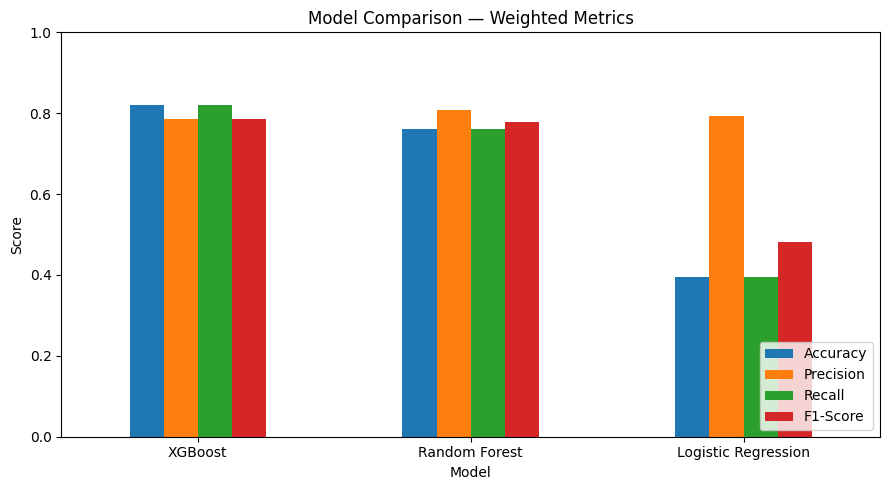

In [20]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(9, 5), rot=0
)
plt.title('Model Comparison — Weighted Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### **8.3 Select Best Model**

In [21]:
best_model_name = results_df.iloc[0]['Model']
best_predictions = model_predictions[best_model_name]

model_objects = {
    'Logistic Regression': logistic_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}
best_model = model_objects[best_model_name]

print('Best model by weighted F1-Score:', best_model_name)

Best model by weighted F1-Score: XGBoost


# **9. Best Model — Detailed Evaluation**

### **9.1 Classification Report**

In [22]:
print(f'{best_model_name} Classification Report')
print(classification_report(y_test, best_predictions, zero_division=0))

XGBoost Classification Report
              precision    recall  f1-score   support

           1       0.57      0.40      0.47       335
           2       0.84      0.96      0.90     29758
           3       0.58      0.26      0.36      5961
           4       0.35      0.03      0.06       954

    accuracy                           0.82     37008
   macro avg       0.58      0.41      0.45     37008
weighted avg       0.79      0.82      0.79     37008



### **9.2 Confusion Matrix**

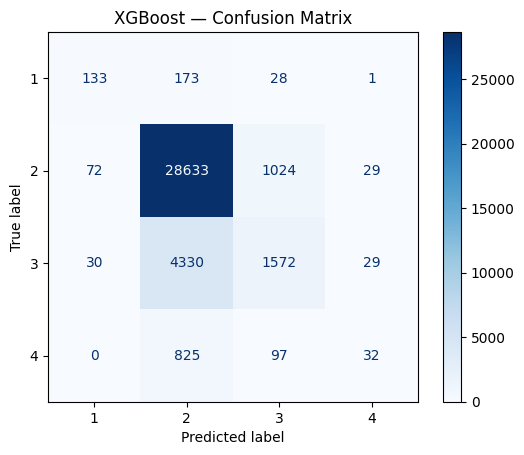

In [23]:
class_labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_predictions, labels=class_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues')
plt.title(f'{best_model_name} — Confusion Matrix')
plt.show()

# **10. Feature Importance**



### **10.1 Random Forest Importance**

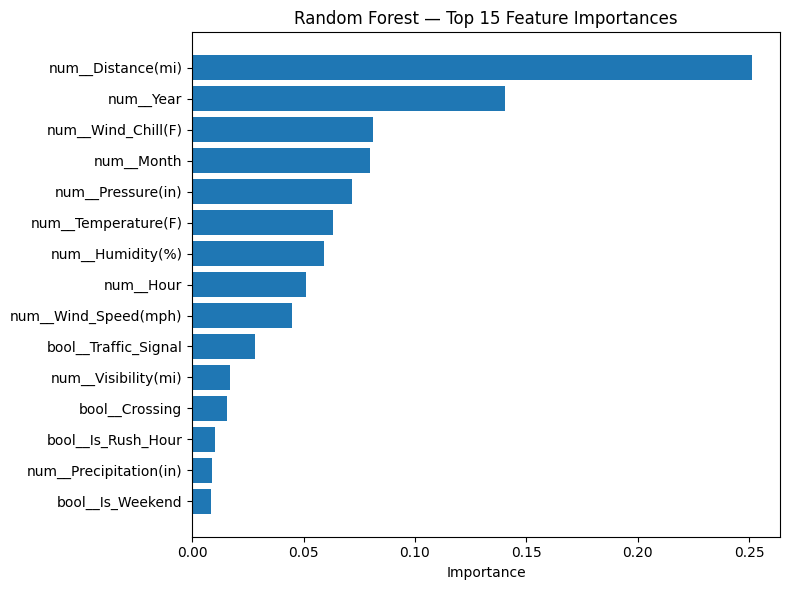

In [24]:
rf_feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
rf_importances = rf_model.named_steps['model'].feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(rf_importance_df['Feature'][::-1], rf_importance_df['Importance'][::-1])
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### **10.2 XGBoost Importance**

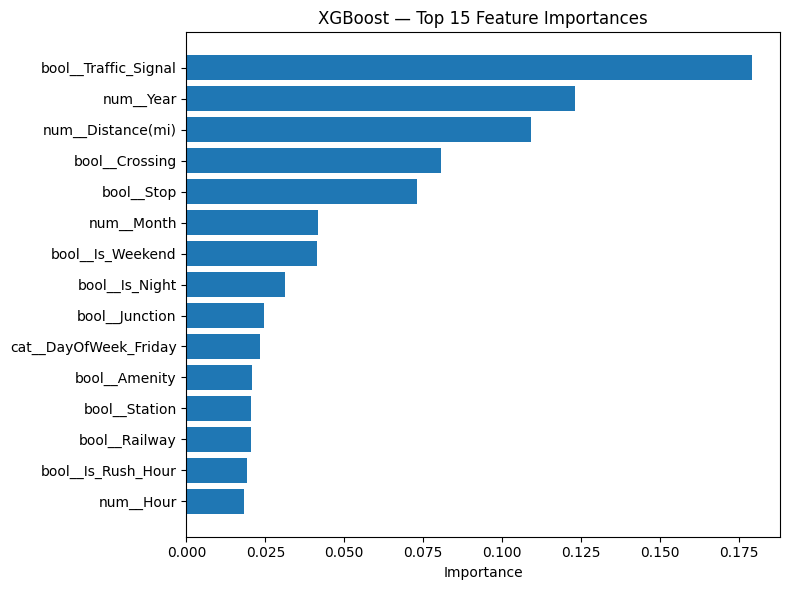

In [25]:
xgb_feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()
xgb_importances = xgb_model.named_steps['model'].feature_importances_

xgb_importance_df = pd.DataFrame({
    'Feature': xgb_feature_names,
    'Importance': xgb_importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(xgb_importance_df['Feature'][::-1], xgb_importance_df['Importance'][::-1])
plt.title('XGBoost — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# **11. Save Best Model**

In [26]:
import joblib


model_filename = 'best_severity_model.pkl'
joblib.dump(best_model, model_filename)
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print(f'Saved {best_model_name}, Preprocessor, and Label Encoder successfully!')

Saved XGBoost, Preprocessor, and Label Encoder successfully!


In [27]:
try:
    from google.colab import files
    files.download(model_filename)
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:

pipeline = joblib.load('best_severity_model.pkl')
print("--- Pipeline Steps ---")
print(pipeline.steps)
model = pipeline.named_steps['model']
print("\n--- Model Parameters ---")
print(model.get_params())
preprocessor = pipeline.named_steps['preprocessor']
print("\n--- Preprocessor Details ---")
print(preprocessor)

--- Pipeline Steps ---
[('preprocessor', ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Distance(mi)', 'Temperature(F)',
                                  'Wind_Chill(F)', 'Humidity(%)',
                                  'Pressure(in)', 'Visibility(mi)',
                                  'Wind_Speed(mph)', 'Precipitation(in)',
                                  'Hour', 'Month', 'Year']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_...
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['DayOfWeek']),
                             

In [29]:
new_data = X_test.iloc[0:5]
predictions = pipeline.predict(new_data)

In [30]:
importances = pipeline.named_steps['model'].feature_importances_
print(importances)

[0.10917685 0.01057865 0.01736278 0.01043375 0.01272409 0.00933677
 0.01050551 0.00959023 0.01818529 0.04155204 0.12303273 0.02315829
 0.00778422 0.01557377 0.00785112 0.00829482 0.00761374 0.00754262
 0.02081003 0.00593554 0.08052258 0.01139176 0.0245095  0.00758022
 0.02039832 0.00307832 0.0205222  0.07308093 0.01092154 0.17906593
 0.04148176 0.01910251 0.03130154]


In [31]:
pipeline.named_steps['model'].set_params(n_estimators=300, max_depth=8)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=4, ...)

# **12. Key Findings**

In [32]:
summary = pd.DataFrame({
    'Item': [
        'Best Model',
        'Best Weighted F1-Score',
        'Best Accuracy',
        'Top Predictive Feature (RF)',
        'Top Predictive Feature (XGBoost)'
    ],
    'Value': [
        best_model_name,
        round(results_df.iloc[0]['F1-Score'], 4),
        round(results_df.iloc[0]['Accuracy'], 4),
        rf_importance_df.iloc[0]['Feature'],
        xgb_importance_df.iloc[0]['Feature']
    ]
})
summary

,Item,Value
0,Best Model,XGBoost
1,Best Weighted F1-Score,0.7868
2,Best Accuracy,0.8206
3,Top Predictive Feature (RF),num__Distance(mi)
4,Top Predictive Feature (XGBoost),bool__Traffic_Signal


**Summary:** Three models were trained on the same preprocessed feature set numeric weather/time variables (scaled), the `DayOfWeek` category (one-hot encoded), and boolean road-infrastructure/time flags. The models are ranked above by weighted F1-Score to account for the class imbalance in `Severity` (Severity 2 dominates the dataset, as found in Part A). The confusion matrix and feature importance charts highlight which severity levels are hardest to separate and which features (e.g. weather conditions, time of day, junction/traffic-signal presence) drive the prediction most.